 ## Gustavo Calin dos Santos 17.01190-6

## Classificação

## **1)** Importação de bibliotecas e classes

In [85]:
# Bibliotecas de cálculo, manipulação de dados e geração de gráficos
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [86]:
# Bibliotecas específicas de Machine Learning
from sklearn.linear_model import LogisticRegression   # Classificador por regressão logística
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split  # Divisão de dados para validação cruzada hold-out
from sklearn.model_selection import cross_val_score   # Validação cruzada k-folds

from sklearn.metrics import accuracy_score, classification_report   # Métricas de qualidade
from sklearn.metrics import ConfusionMatrixDisplay    # Visualização "gráfica" da matriz de confusão

from sklearn.model_selection import GridSearchCV      # Importação da biblioteca necessária para a busca em grade (Grid Search)

### **2)** Leitura dos dados

In [87]:
caminho_arquivo = "/content/drive/MyDrive/Colab Notebooks/Ciência de Dados e Inteligência Artificial/Aprendizado de Maquina/Datasets/A02EX1_carros.csv"

df = pd.read_csv(caminho_arquivo)
display(df)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,USA,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,USA,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,USA,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,USA,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,USA,ford torino
...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86,2790,15.6,82,USA,ford mustang gl
388,44.0,4,97.0,52,2130,24.6,82,Europe,vw pickup
389,32.0,4,135.0,84,2295,11.6,82,USA,dodge rampage
390,28.0,4,120.0,79,2625,18.6,82,USA,ford ranger


### **2.1)** Características gerais

In [88]:
# Contagem de classes da resposta/target
df['origin'].value_counts()

,count
origin,
USA,245
Asia,79
Europe,68


### **2.2)** Gráficos

In [89]:
# Opção usando a biblioteca Seaborn
import seaborn as sns

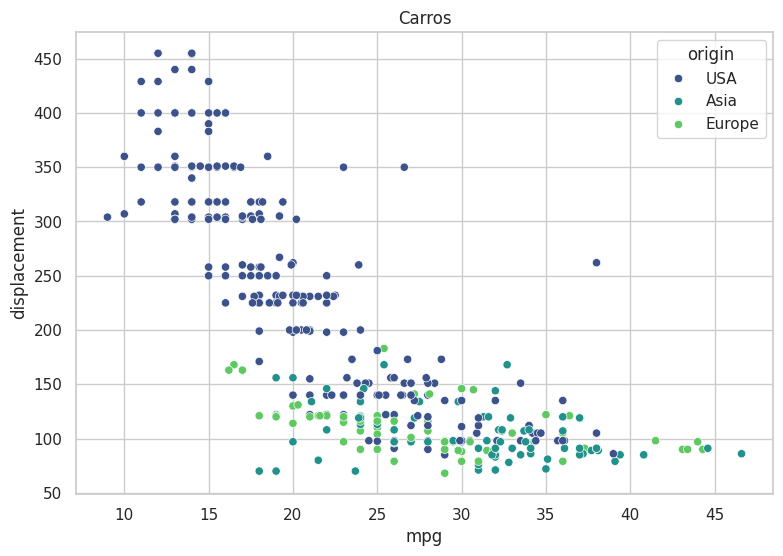

In [90]:
# Diagrama de dispersão entre comprimento e largura da pétala
# Ajustes da figura
# Tamanho do gráfico (polegadas): largura = 9, altura = 6
plt.figure(figsize = (9,6))

# Título e rótulos dos eixos
plt.title("Carros")
plt.xlabel("mpg")
plt.ylabel("displacement")

sns.scatterplot(data = df, x = 'mpg', y = 'displacement',
                palette = 'viridis', hue = 'origin')
plt.show()

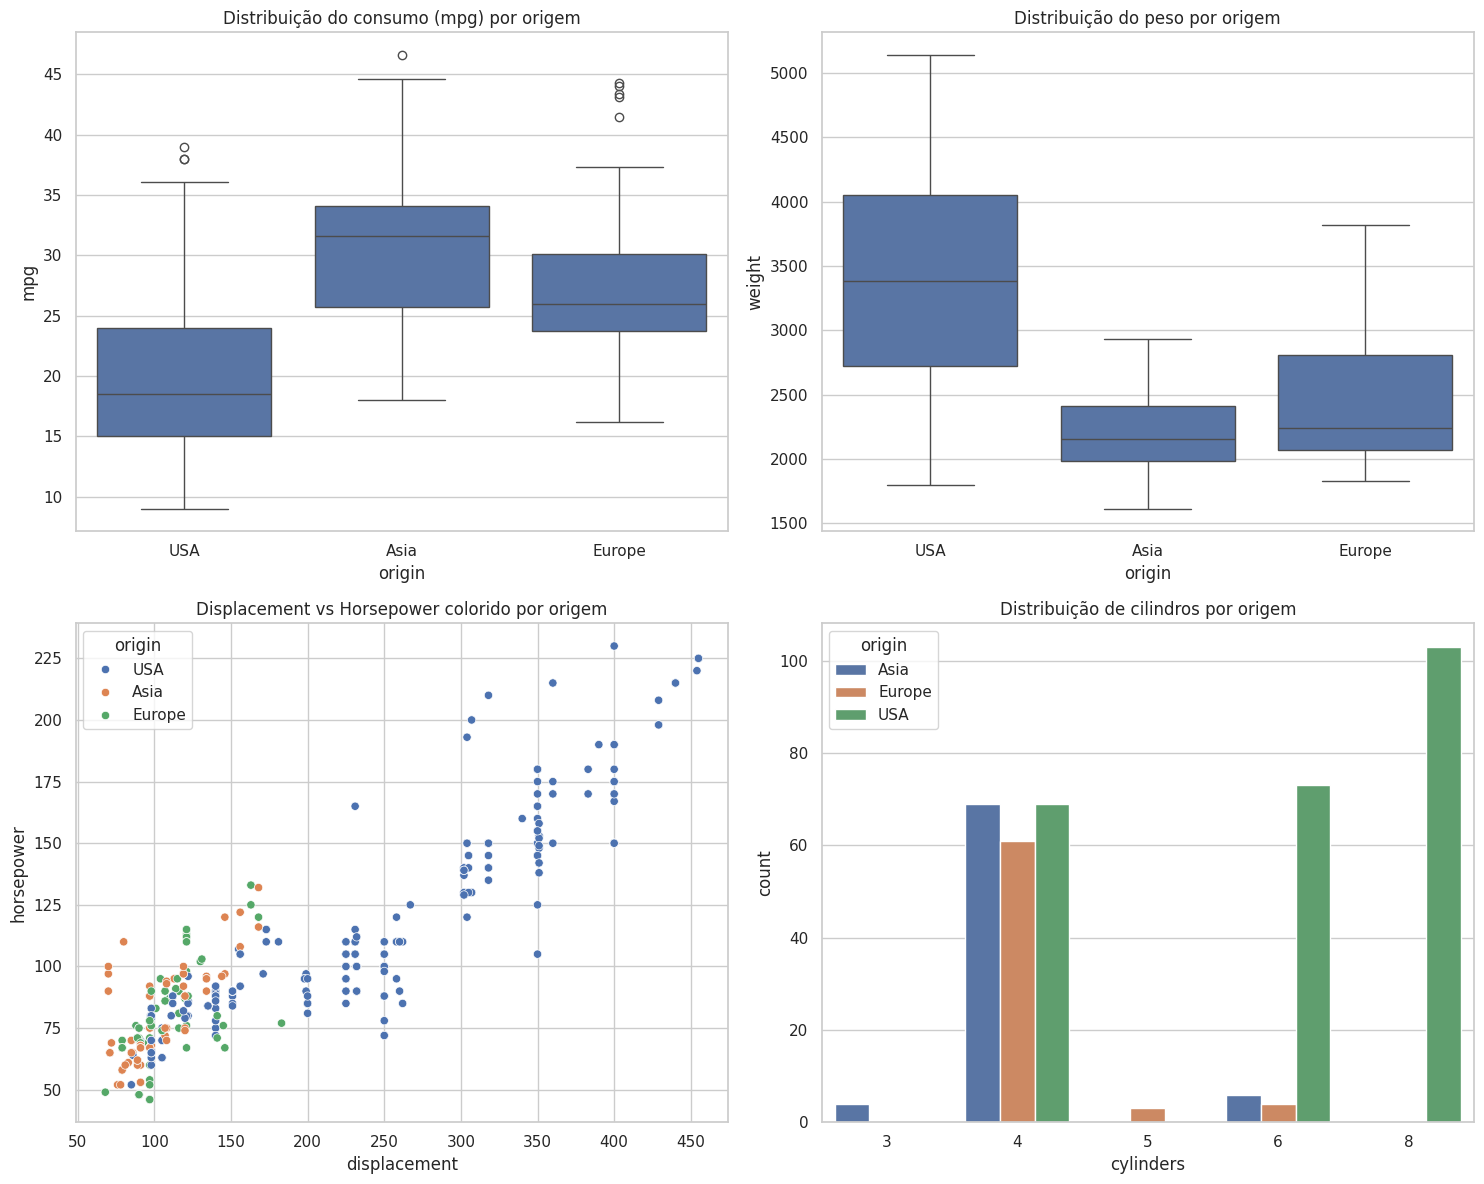

In [91]:
# Ajustar o estilo dos gráficos
sns.set(style="whitegrid")

# Criar uma figura com múltiplos gráficos
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Distribuição do consumo (mpg) por origem
sns.boxplot(x="origin", y="mpg", data=df, ax=axes[0, 0])
axes[0, 0].set_title("Distribuição do consumo (mpg) por origem")

# Gráfico 2: Distribuição do peso por origem
sns.boxplot(x="origin", y="weight", data=df, ax=axes[0, 1])
axes[0, 1].set_title("Distribuição do peso por origem")

# Gráfico 3: Scatterplot entre potência e deslocamento colorido pela origem
sns.scatterplot(x="displacement", y="horsepower", hue="origin", data=df, ax=axes[1, 0])
axes[1, 0].set_title("Displacement vs Horsepower colorido por origem")

# Gráfico 4: Contagem de cilindros por origem
sns.countplot(x="cylinders", hue="origin", data=df, ax=axes[1, 1])
axes[1, 1].set_title("Distribuição de cilindros por origem")

# Exibir os gráficos
plt.tight_layout()
plt.show()

## **3)** Seleção e pré-processamento de atributos

In [92]:
X = df.drop(columns = ['car name', 'model year', 'origin'])   # Atributos: 4 dimensões das flores
y = df['origin']                             # Reposta: espécie. Opção: df['target']

In [93]:
# Pré-processamento 1: divisão em dados de treino (80%) e teste (20%)
# IMPORTANTE: sem o controle do parâmetro 'random_state', diferentes partições
# do conjunto de dados serão retornadas a cada execução da função de divisão
# o stratify divide igualmente as classes de treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X,y,train_size = 0.8,
                                                        random_state = 42,
                                                        stratify = y)

In [94]:
# Pré-processamento 2: PADRONIZAÇÃO dos atributos (treino e
# teste) segundo a média e desvio padrão DO CONJUNTO DE TREINO

# Importação da biblioteca de padronização de atributos
from sklearn.preprocessing import StandardScaler

# Criação de instância e treinamento de um objeto "escalonador"
escalonador = StandardScaler()
escalonador.fit(X_treino)

# Padronização dos dados de treino e teste
X_treino_Padr = escalonador.transform(X_treino)
X_teste_Padr = escalonador.transform(X_teste)

In [95]:
# Conversão dos conjuntos padronizados em DataFrames
X_treino_Padr = pd.DataFrame(data = X_treino_Padr,columns = X_treino.columns)
X_teste_Padr = pd.DataFrame(data = X_teste_Padr,columns = X_treino.columns)

## **4)** Classificação por regressão logística

In [96]:
clf_RL = LogisticRegression(solver = 'newton-cg')
clf_RL.fit(X_treino_Padr,y_treino)

print("Iterações do algoritmo de treino:",clf_RL.n_iter_)

Iterações do algoritmo de treino: [8]


In [97]:
clf_RL = LogisticRegression()
clf_RL.fit(X_treino_Padr,y_treino)

print("Iterações do algoritmo de treino:",clf_RL.n_iter_)

Iterações do algoritmo de treino: [27]


## **4.1)** Validação cruzada *hold-out*

In [98]:
y_previsto = clf_RL.predict(X_teste_Padr)

# Cálculo da acurácia (nos dados de teste)
print("Acurácia =",accuracy_score(y_true = y_teste,y_pred = y_previsto))

Acurácia = 0.7721518987341772


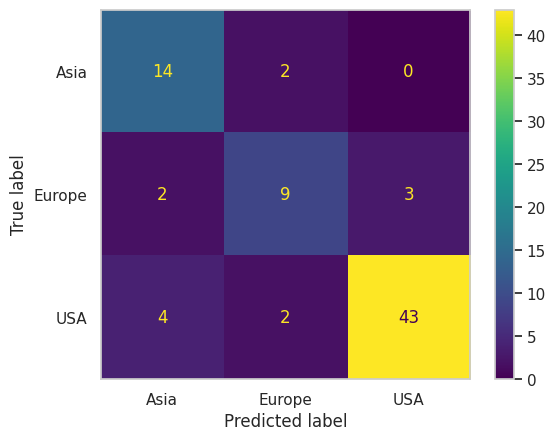

In [128]:
# Representação "gráfica" da matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_true = y_teste,y_pred = y_previsto)
plt.grid(None)
plt.show()

## **5)** Treinamento do classificador *KNN*

In [100]:
# Treinamento do classificador com os dados padronizados
clf_KNN = KNeighborsClassifier()
clf_KNN.fit(X_treino_Padr,y_treino)

KNeighborsClassifier()

In [101]:
# Cálculo das classificações previstas usando os dados de teste
y_previsto = clf_KNN.predict(X_teste_Padr)

# Cálculo da acurácia (nos dados de teste)
print("Acurácia =",accuracy_score(y_true = y_teste,y_pred = y_previsto))

Acurácia = 0.7974683544303798


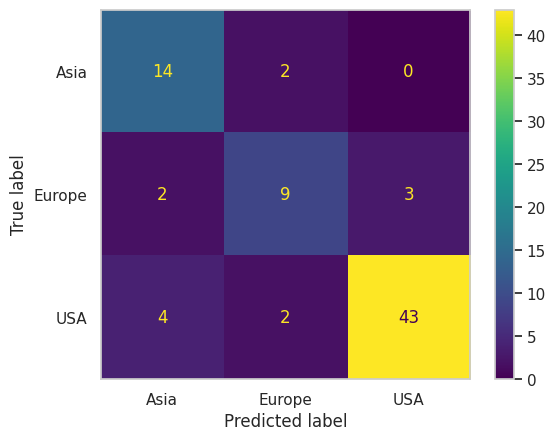

In [129]:
# Representação "gráfica" da matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_true = y_teste,y_pred = y_previsto)
plt.grid(None)
plt.show()

In [103]:
# Relatório das métricas de qualidade
print(classification_report(y_true = y_teste,y_pred = y_previsto,digits = 4))

              precision    recall  f1-score   support

        Asia     0.6522    0.9375    0.7692        16
      Europe     0.7143    0.3571    0.4762        14
         USA     0.8776    0.8776    0.8776        49

    accuracy                         0.7975        79
   macro avg     0.7480    0.7241    0.7077        79
weighted avg     0.8030    0.7975    0.7845        79



## **5.1)** Validação cruzada *hold-out*

In [104]:
# Validação cruzada k-folds (com k = 10), avaliando a ACURÁCIA
# Padronização do conjunto COMPLETO de atributos
X_Padr = escalonador.transform(X)

aval = cross_val_score(clf_KNN,X_Padr,y,cv = 10,scoring = 'accuracy')
M = aval.mean()     # Média das avaliações
DP = aval.std()     # Desvio padrão das avaliações
CV_aval = 100*DP/M  # Coeficiente de variação (%) das avaliações

print("Acurácias obtidas:",aval)
print("")   # "Imprime" uma linha em branco
print("Acurácia média =",M)
print("Coeficiente de variação (%) =",CV_aval)

Acurácias obtidas: [0.85       0.725      0.82051282 0.82051282 0.76923077 0.79487179
 0.76923077 0.82051282 0.51282051 0.71794872]

Acurácia média = 0.7600641025641026
Coeficiente de variação (%) = 12.098722886451998


## **5.2) Busca em grade</u> para o classificador *KNN*

In [105]:
GradeHP_K = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}

In [106]:
# Definição do classificador usado na busca, SE NECESSÁRIO
# clf_SVM = SVC()

# Criação de instância da grade de busca + treinamentos e testes (com validação cruzada)
GradeBusca = GridSearchCV(clf_KNN,param_grid = GradeHP_K,cv = 10,scoring = 'accuracy')
GradeBusca.fit(X_Padr,y)


GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]},
             scoring='accuracy')

In [107]:
# Exibição da melhor solução obtida (não é "ótima"!)
print("Melhor solução:",GradeBusca.best_estimator_)

print("")   # "Imprime" uma linha em branco
print("Melhor valor de 'k' =",GradeBusca.best_estimator_.n_neighbors)

Melhor solução: KNeighborsClassifier(n_neighbors=3)

Melhor valor de 'k' = 3


In [108]:
clf_KNN = KNeighborsClassifier(n_neighbors=3)
clf_KNN.fit(X_treino_Padr,y_treino)

KNeighborsClassifier(n_neighbors=3)

In [109]:
# Cálculo das classificações previstas usando os dados de teste
y_previsto = clf_KNN.predict(X_teste_Padr)

# Cálculo da acurácia
print("Acurácia =",accuracy_score(y_true = y_teste,y_pred = y_previsto))

Acurácia = 0.759493670886076


In [110]:
# Relatório das métricas de qualidade
print(classification_report(y_true = y_teste,y_pred = y_previsto,digits = 4))

              precision    recall  f1-score   support

        Asia     0.5200    0.8125    0.6341        16
      Europe     0.6667    0.4286    0.5217        14
         USA     0.9111    0.8367    0.8723        49

    accuracy                         0.7595        79
   macro avg     0.6993    0.6926    0.6761        79
weighted avg     0.7886    0.7595    0.7620        79



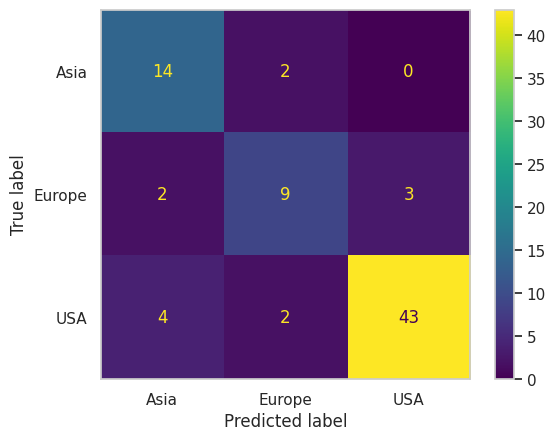

In [130]:
# Representação "gráfica" da matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_true = y_teste,y_pred = y_previsto)
plt.grid(None)
plt.show()

## **6)** Classificação por *SVM*

In [112]:
from sklearn.svm import SVC

## **6.1)** Treinamento do classificador [por] *SVM*

In [113]:
# Criação de instância e treinamento do classificador [por] SVM
# COMPLETAR. NOME SUGERIDO: 'clf_SVM'
clf_SVM = SVC()
clf_SVM.fit(X_treino_Padr,y_treino)

SVC()

## **6.2)** Validação cruzada *hold-out*

In [114]:
# Cálculo das classificações previstas usando os dados de teste
y_previsto = clf_SVM.predict(X_teste_Padr)

# Cálculo da acurácia
print("Acurácia =",accuracy_score(y_true = y_teste,y_pred = y_previsto))

Acurácia = 0.7974683544303798


In [115]:
# Relatório das métricas de qualidade
print(classification_report(y_true = y_teste,y_pred = y_previsto,digits = 4))

              precision    recall  f1-score   support

        Asia     0.5652    0.8125    0.6667        16
      Europe     0.8333    0.3571    0.5000        14
         USA     0.9000    0.9184    0.9091        49

    accuracy                         0.7975        79
   macro avg     0.7662    0.6960    0.6919        79
weighted avg     0.8204    0.7975    0.7875        79



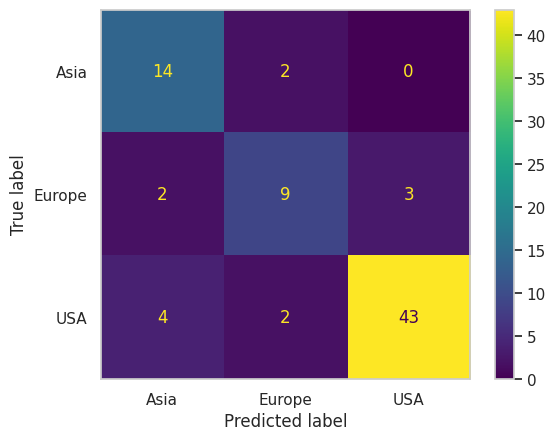

In [131]:
# Representação "gráfica" da matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_true = y_teste,y_pred = y_previsto)
plt.grid(None)
plt.show()

## **6.3)** Validação cruzada

In [117]:
# Validação cruzada k-folds (com k = 10), avaliando a ACURÁCIA
# Padronização do conjunto COMPLETO de atributos
X_Padr = escalonador.transform(X)

aval = cross_val_score(clf_SVM,X_Padr,y,cv = 10,scoring = 'accuracy')
M = aval.mean()     # Média das avaliações
DP = aval.std()     # Desvio padrão das avaliações
CV_aval = 100*DP/M  # Coeficiente de variação (%) das avaliações

print("Acurácias obtidas:",aval)
print("")   # "Imprime" uma linha em branco
print("Acurácia média =",M)
print("Coeficiente de variação (%) =",CV_aval)

Acurácias obtidas: [0.775      0.7        0.84615385 0.79487179 0.76923077 0.74358974
 0.66666667 0.76923077 0.56410256 0.69230769]

Acurácia média = 0.7321153846153846
Coeficiente de variação (%) = 10.293965934074707


## **6.4)** Busca em grade</u> para o classificador *SVM*

In [118]:
# Importação da biblioteca necessária para a busca em grade (Grid Search)
from sklearn.model_selection import GridSearchCV

In [119]:
GradeHP = {'C': [0.001, 0.1, 1, 10, 100, 1000],
           'gamma': [0.001, 0.1, 1, 10, 100, 1000]}

In [120]:
# Definição do classificador usado na busca, SE NECESSÁRIO
# clf_SVM = SVC()

# Criação de instância da grade de busca + treinamentos e testes (com validação cruzada)
GradeBusca = GridSearchCV(clf_SVM,param_grid = GradeHP,cv = 10,scoring = 'accuracy')
GradeBusca.fit(X_Padr,y)


GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': [0.001, 0.1, 1, 10, 100, 1000],
                         'gamma': [0.001, 0.1, 1, 10, 100, 1000]},
             scoring='accuracy')

In [121]:
# Exibição da melhor solução obtida (não é "ótima"!)
print("Melhor solução:",GradeBusca.best_estimator_)

print("")   # "Imprime" uma linha em branco
print("Melhor valor de 'C' =",GradeBusca.best_estimator_.C)
print("Melhor valor de 'gamma' =",GradeBusca.best_estimator_.gamma)

Melhor solução: SVC(C=100, gamma=0.1)

Melhor valor de 'C' = 100
Melhor valor de 'gamma' = 0.1


In [122]:
clf_SVM = SVC(C = 100, gamma = 0.1)
clf_SVM.fit(X_treino_Padr,y_treino)

SVC(C=100, gamma=0.1)

In [123]:
# Cálculo das classificações previstas usando os dados de teste
y_previsto = clf_SVM.predict(X_teste_Padr)

# Cálculo da acurácia
print("Acurácia =",accuracy_score(y_true = y_teste,y_pred = y_previsto))

Acurácia = 0.8354430379746836


In [124]:
# Relatório das métricas de qualidade
print(classification_report(y_true = y_teste,y_pred = y_previsto,digits = 4))

              precision    recall  f1-score   support

        Asia     0.7000    0.8750    0.7778        16
      Europe     0.6923    0.6429    0.6667        14
         USA     0.9348    0.8776    0.9053        49

    accuracy                         0.8354        79
   macro avg     0.7757    0.7985    0.7832        79
weighted avg     0.8443    0.8354    0.8372        79



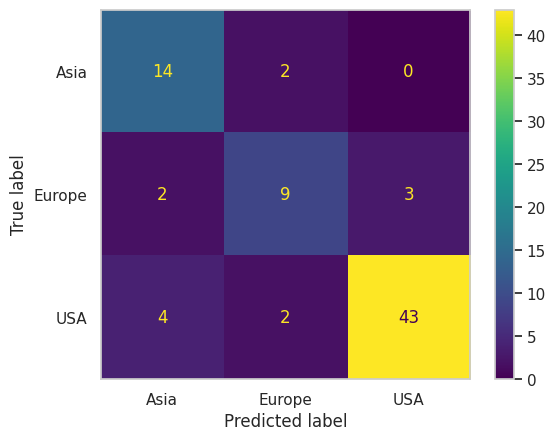

In [132]:
# Representação "gráfica" da matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_true = y_teste,y_pred = y_previsto)
plt.grid(None)
plt.show()